# Three-Lens IL System: Calibration from DAC Tables

This notebook calibrates the intermediate-lens (IL) system of a TEM from
pre-parsed DAC tables using an **analytic closed-form solver** for the two
imaging constraints ($A = m$, $B = 0$).

## Notebook structure

| Section | Purpose |
|---------|---------|
| **Data** | Load 16-bit-normalised DAC tables for imaging and camera-length modes |
| **Physics** | Derivation of the analytic solver |
| **CAD priors** | Distance estimates from pixel measurements of the microscope column |
| **Analytic functions** | `phi2_exact`, `phi1_exact`, `model_at_data`, `make_residuals` |
| **Fit** | Broad search over sign combinations and $\alpha$ seeds, followed by refinement |
| **Evaluation** | Model-vs-data plots |
| **Export** | Convert fitted distances to z-positions and write to `microscope.toml` |


## Physical setup

Three intermediate lenses (IL1, IL2, IL3) sit between the objective and the
projector. The microscope operates in two modes that share the same IL optics
but differ in object-plane distance $d_1$.

| Mode | Target quantity | Relation |
|------|----------------|----------|
| **Imaging** | system magnification $M_\text{sys}$ | $M_\text{sys} = M_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |
| **Camera length** | $\text{CL}$ [mm] | $\text{CL} = f_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |

Scale factors $s_\text{img}$, $s_\text{cam}$ absorb the unknown
$M_\text{obj}$, $M_\text{proj}$, and $f_\text{obj}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_MEM_FRACTION"] = "0.1"

%matplotlib widget
# ==== Distance-first compact data tables ====
# These are the same parsed 16-bit-normalized values previously derived from
# the raw hex service-menu tables.

mags_ref = np.array([30000.0, 40000.0, 50000.0, 60000.0, 80000.0, 100000.0,
                     120000.0, 150000.0, 200000.0, 250000.0, 300000.0,
                     400000.0, 500000.0, 600000.0], dtype=float)

cl_ref = np.array([80.0, 100.0, 120.0, 150.0, 200.0, 250.0, 300.0, 400.0,
                   500.0, 600.0, 800.0, 1000.0, 1200.0, 1500.0, 2000.0], dtype=float)

x_img = np.array([
    [0.621612548828125, 0.637542724609375, 0.65020751953125, 0.656494140625,
     0.659820556640625, 0.65625, 0.65557861328125, 0.6538238525390625,
     0.6514434814453125, 0.6510009765625, 0.6485595703125,
     0.64654541015625, 0.6449737548828125, 0.643798828125],
    [0.379364013671875, 0.379364013671875, 0.3929443359375, 0.4151611328125,
     0.443389892578125, 0.489349365234375, 0.489349365234375,
     0.5163726806640625, 0.5839080810546875, 0.5839080810546875,
     0.620208740234375, 0.67596435546875, 0.72369384765625,
     0.7647552490234375],
    [0.6062774658203125, 0.5423583984375, 0.5223236083984375,
     0.4974517822265625, 0.468048095703125, 0.4453887939453125,
     0.4238128662109375, 0.398040771484375, 0.360504150390625,
     0.3326873779296875, 0.2955322265625, 0.242523193359375,
     0.1968994140625, 0.1540679931640625],
], dtype=float)

x_cam = np.array([
    [0.3143310546875, 0.3218536376953125, 0.3208160400390625,
     0.325164794921875, 0.325164794921875, 0.3262176513671875,
     0.3267974853515625, 0.3269500732421875, 0.3263397216796875,
     0.3261871337890625, 0.3243865966796875, 0.3243865966796875,
     0.3234100341796875, 0.3220367431640625, 0.3204345703125],
    [0.6826324462890625, 0.6861724853515625, 0.690277099609375,
     0.6940460205078125, 0.70257568359375, 0.7133636474609375,
     0.7209320068359375, 0.7436981201171875, 0.7699737548828125,
     0.785888671875, 0.822265625, 0.8544921875, 0.8896484375,
     0.93798828125, 0.999755859375],
    [0.57269287109375, 0.5672454833984375, 0.5620269775390625,
     0.55426025390625, 0.5417327880859375, 0.529632568359375,
     0.5180511474609375, 0.4975128173828125, 0.4763641357421875,
     0.45703125, 0.42138671875, 0.390625, 0.358642578125,
     0.311767578125, 0.216796875],
], dtype=float)

print(f"Imaging:  {len(mags_ref)} points,  mag {mags_ref.min():.0f}..{mags_ref.max():.0f}")
print(f"Camera:   {len(cl_ref)} points,  CL {cl_ref.min():.0f}..{cl_ref.max():.0f} mm")
print("Compact data loaded. Proceed directly to distance fit (cell 4).")

Imaging:  14 points,  mag 30000..600000
Camera:   15 points,  CL 80..2000 mm
Compact data loaded. Proceed directly to distance fit (cell 4).


## Analytical Solver (Physics Explainer)

### Magnetic lens optics recap

The optical power (inverse focal length) of a magnetic round lens is

$$\phi \;=\; \frac{e}{8\,m_e\,U^*}\;\int_{-\infty}^{\infty} B_z^2(z)\,dz$$

where $U^* = U(1 + eU/2m_ec^2)$ is the relativistic accelerating potential.
Since $B_z \propto NI$, we get $\phi \propto (NI)^2$ with a proportionality
constant that depends only on geometry (bore, gap, pole pieces):

$$\phi_k \;=\; \underbrace{\alpha_{\mathrm{geom},k} N_k^2 I_{\max}^2}_{\alpha_k}\, x_k^2$$

The fit uses lumped constants $\alpha_k$. If lens geometries are similar,
$\alpha_k$ differences mainly reflect turns-ratio differences.

### Transfer-matrix model

Each thin lens and drift is

$$P(d)=\begin{pmatrix}1 & d\\0 & 1\end{pmatrix},\qquad
L(\phi)=\begin{pmatrix}1 & 0\\-\phi & 1\end{pmatrix}$$

and the IL block is

$$M=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)L(\phi_1)P(d_1).$$

Define $A=M_{00}$ and $B=M_{01}$.

For an imaging solution at target IL magnification $m$, we require:

- magnification constraint: $A=m$
- focus constraint: $B=0$

### Why the solver is analytic

Write

$$M = M_{\text{rest}}\,L(\phi_1)\,P(d_1),$$

with $M_{\text{rest}}=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)$.
Then top-row terms can be written as

$$A = a - b\phi_1,\qquad B = a d_1 + b(1-d_1\phi_1),$$

where $a,b$ depend only on $(\phi_2,\phi_3)$.
Substitute $\phi_1=(a-m)/b$ from $A=m$ into $B=0$:

$$a d_1 + b - d_1(a-m)=0 \Rightarrow b + d_1 m = 0.$$

So $\phi_1$ cancels out, and we first solve

$$M_{\text{rest}}[0,1] = -d_1 m.$$

This is linear in $\phi_2$ for fixed $\phi_3$, giving a closed form used in code
(`phi2_exact`). Then $\phi_1$ follows from $A=m$ in another closed form
(`phi1_exact`).

### Inverse fit strategy used here

At each measured operating point, we use the measured $x_3$ to set
$\phi_3=\alpha_3 x_3^2$, then compute:

1. $\phi_2^*=\texttt{phi2\_exact}(\phi_3,m,\mathbf d)$
2. $\phi_1^*=\texttt{phi1\_exact}(\phi_2^*,\phi_3,m,\mathbf d)$
3. $x_1^*=\sqrt{\phi_1^*/\alpha_1}$ and $x_2^*=\sqrt{\phi_2^*/\alpha_2}$

Residuals compare $(x_1^*,x_2^*)$ against measured $(x_1,x_2)$.
By construction, each valid point satisfies $A=m$ and $B=0$ exactly.

### Parameters fitted

Nine fit parameters are used:

- distances: $d_1^{img}, d_1^{cam}, d_2, d_4$
- lens constants: $\alpha_1,\alpha_2,\alpha_3$
- mode scales: $s_{img}, s_{cam}$

### Workflow intent

This notebook now runs in a distance-first way:

1. estimate distances and lens constants
2. report distance analytics first
3. evaluate model-vs-data with plots afterward

In [2]:
from scipy.optimize import least_squares, brentq
from optics_helpers import PX_TO_M

# ── CAD priors and shared CAD geometry constants ──────────────────────
# Distance estimates from pixel measurements of the microscope column
# photograph (see measure_microscope_geometry notebook).
# All distances are normalised to d3 = 1 (the IL2→IL3 gap).

PX_SAMPLE = 575
PX_IL1 = 672
PX_IL2 = 709
PX_IL3 = 739
PX_PL1 = 764
PX_SCREEN = 920

PX_TO_MM = PX_TO_M * 1e3
D3_MM = (PX_IL3 - PX_IL2) * PX_TO_MM  # d3 in mm (reference length)

# Shared absolute CAD distances used by later export/transport cells.
CAD_SAMPLE_TO_DET_MM = (PX_SCREEN - PX_SAMPLE) * PX_TO_MM
CAD_PL1_TO_DET_MM = (PX_SCREEN - PX_PL1) * PX_TO_MM

CAD = {
    'd2':     (PX_IL2 - PX_IL1) * PX_TO_MM / D3_MM,   # IL1→IL2
    'd4':     (PX_PL1 - PX_IL3) * PX_TO_MM / D3_MM,   # IL3→projector/PL1
    'd1_img': (PX_IL1 - 666)    * PX_TO_MM / D3_MM,   # object→IL1 (imaging mode)
    'd1_cam': (PX_IL1 - 576)    * PX_TO_MM / D3_MM,   # object→IL1 (camera-length mode)
}

# Prior weights: how strongly to pull fitted distances toward CAD values.
# d1_img prior is zeroed because the CAD estimate rests on only 6 pixels.
CAD_SIGMA = 0.20       # fractional uncertainty on each CAD distance
W_CAD     = 0.35       # weight for d2, d4 priors
W_CAD_D1I = 0.0        # weight for d1_img prior (disabled)

print(f"Reference gap  d3 = {D3_MM:.1f} mm")
print(f"\nCAD distance priors (normalised to d3 = 1):")
for k, v in CAD.items():
    print(f"  {k:7s} = {v:.3f}")
print(f"\nShared CAD distances:")
print(f"  sample->detector = {CAD_SAMPLE_TO_DET_MM:.1f} mm")
print(f"  PL1->detector    = {CAD_PL1_TO_DET_MM:.1f} mm")


Reference gap  d3 = 62.5 mm

CAD distance priors (normalised to d3 = 1):
  d2      = 1.233
  d4      = 0.833
  d1_img  = 0.200
  d1_cam  = 3.200

Shared CAD distances:
  sample->detector = 718.8 mm
  PL1->detector    = 325.0 mm


## Analytic solver functions

These two functions implement the closed-form solutions derived in the physics
cell above. For given lens power $\phi_3$, target IL magnification $m$, and
distances $\mathbf{d} = (d_1, d_2, d_3, d_4)$:

- **`phi2_exact`** solves the combined $B = 0$, $A = m$ constraint for $\phi_2$
- **`phi1_exact`** solves $A = m$ for $\phi_1$ once $\phi_2$ and $\phi_3$ are known

In [3]:
# ── Closed-form solutions for phi2 and phi1 ──────────────────────────

BALANCE_EXPONENT = 0.35


def phi2_exact(phi3, m, d):
    """Solve the combined B=0, A=m constraint for phi2.

    Given phi3, target magnification m, and distances d = (d1, d2, d3, d4),
    returns the unique phi2 satisfying both imaging constraints.
    """
    d1, d2, d3, d4 = d
    num = d1 * m + (d2 + d3 + d4) - (d2 + d3) * d4 * phi3
    den = d2 * ((d3 + d4) - d3 * d4 * phi3)
    return num / den if abs(den) > 1e-30 else np.nan


def phi1_exact(phi2, phi3, m, d):
    """Solve A=m for phi1 with phi2, phi3 already known.

    Returns the lens power phi1 that gives the target magnification m.
    """
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3 + d4) * phi2 - d4 * phi3 + d3 * d4 * phi2 * phi3
    A1 = -(d2 + d3 + d4) + d2 * (d3 + d4) * phi2 + (d2 + d3) * d4 * phi3 - d2 * d3 * d4 * phi2 * phi3
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan


def model_at_data(m_arr, x3_data, d, alpha):
    """Evaluate model-predicted DAC values at calibration points.

    For each operating point, fixes x3 to the measured value, then uses
    phi2_exact and phi1_exact to compute the predicted x1, x2.

    Returns (3, N) array of predicted [x1, x2, x3] DAC values.
    """
    out = np.full((3, len(m_arr)), np.nan)
    for j, m in enumerate(m_arr):
        p3 = alpha[2] * x3_data[j]**2
        p2 = phi2_exact(p3, m, d)
        if (not np.isfinite(p2)) or p2 <= 0:
            continue
        p1 = phi1_exact(p2, p3, m, d)
        if (not np.isfinite(p1)) or p1 <= 0:
            continue
        out[0, j] = np.sqrt(p1 / alpha[0])
        out[1, j] = np.sqrt(p2 / alpha[1])
        out[2, j] = x3_data[j]
    return out


def _solve_m_obj_from_delta(delta, u):
    """Infer |M_obj| from (d1_cam - d1_img) and sample-to-objective distance."""
    if delta <= 0.0 or u <= 0.0:
        return None
    r = delta / u
    disc = r * r + 4.0 * r
    if disc <= 0.0:
        return None
    return 0.5 * (r + np.sqrt(disc))


def plateau_weights(values):
    """Downweight repeated DAC plateaus caused by table quantisation."""
    unique_vals, counts = np.unique(values, return_counts=True)
    count_map = dict(zip(unique_vals.tolist(), counts.tolist()))
    return np.array([count_map[val]**-0.5 for val in values], dtype=float)


# Balance the fit so flatter DAC curves are not overwhelmed by the higher-span ones.
img_span = np.ptp(x_img, axis=1)
cam_span = np.ptp(x_cam, axis=1)
img_weights = (np.median(img_span) / np.maximum(img_span, 1e-6))**BALANCE_EXPONENT
cam_weights = (np.median(cam_span) / np.maximum(cam_span, 1e-6))**BALANCE_EXPONENT

# Additional pointwise weights reduce the leverage of repeated DAC plateaus.
img_plateau_weights = np.vstack([plateau_weights(x_img[k]) for k in range(3)])
cam_plateau_weights = np.vstack([plateau_weights(x_cam[k]) for k in range(3)])
img_point_weights = img_weights[:, None] * img_plateau_weights
cam_point_weights = cam_weights[:, None] * cam_plateau_weights

def make_residuals(si, sc, w_cad_d1i=W_CAD_D1I):
    """Build the residual function for least_squares.

    Parameters
    ----------
    si, sc : +1 or -1
        Sign of the IL magnification in imaging / camera-length mode.
    w_cad_d1i : float
        Weight for the d1_img CAD prior (can be adjusted between stages).

    The 9-element parameter vector is:
        [d1_img, d1_cam, d2, d4, log(alpha1), log(alpha2), log(alpha3),
         log(s_img), log(s_cam)]
    """
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i, d_c = [d1i, d2, 1.0, d4], [d1c, d2, 1.0, d4]
        res = []
        for x_data, targets, d, s, sign, weights in [
            (x_img, mags_ref, d_i, s_i, si, img_point_weights),
            (x_cam, cl_ref,   d_c, s_c, sc, cam_point_weights),
        ]:
            for j in range(x_data.shape[1]):
                m = sign * s * targets[j]
                p3 = alpha[2] * x_data[2, j]**2
                p2s = phi2_exact(p3, m, d)
                if (not np.isfinite(p2s)) or p2s <= 0:
                    res.extend([1.0, 1.0])
                    continue
                p1s = phi1_exact(p2s, p3, m, d)
                if (not np.isfinite(p1s)) or p1s <= 0:
                    res.extend([1.0, 1.0])
                    continue
                res.append(weights[0, j] * (np.sqrt(p1s / alpha[0]) - x_data[0, j]))
                res.append(weights[1, j] * (np.sqrt(p2s / alpha[1]) - x_data[1, j]))
        # CAD distance priors
        for val, ref in [(d2, CAD['d2']), (d4, CAD['d4'])]:
            res.append(W_CAD * (val - ref) / (CAD_SIGMA * ref))
        res.append(w_cad_d1i * (d1i - CAD['d1_img']) / (CAD_SIGMA * CAD['d1_img']))
        res.append(W_CAD / 3 * (d1c - CAD['d1_cam']) / (CAD_SIGMA * CAD['d1_cam']))
        return np.array(res)
    return fn


# Parameter bounds
lb = np.array([0.05, 0.10, 0.50, 0.30,
               np.log(0.01), np.log(0.01), np.log(0.01),
               np.log(1e-7), np.log(1e-7)])
ub = np.array([0.80, 7.0, 2.60, 1.80,
               np.log(1000), np.log(1000), np.log(1000),
               np.log(1.0), np.log(1.0)])

# Initial guess seeded from CAD distances
p0_base = [CAD['d1_img'], CAD['d1_cam'], CAD['d2'], CAD['d4'],
           0, 0, 0, np.log(1/3000), np.log(1/230)]

print("Analytic functions and residual builder defined.")
print(f"Parameter bounds: {len(lb)} parameters")
print(f"  Distances: d1_img in [{lb[0]:.2f}, {ub[0]:.2f}], d1_cam in [{lb[1]:.2f}, {ub[1]:.2f}]")
print(f"  d2 in [{lb[2]:.2f}, {ub[2]:.2f}], d4 in [{lb[3]:.2f}, {ub[3]:.2f}]")
print(f"Residual weighting exponent = {BALANCE_EXPONENT:.2f}")
print(f"Residual weighting  imaging = {img_weights.round(3)},  camera = {cam_weights.round(3)}")
print(f"Plateau weighting   imaging repeats = {np.unique(img_plateau_weights).round(3)},  camera repeats = {np.unique(cam_plateau_weights).round(3)}")


Analytic functions and residual builder defined.
Parameter bounds: 9 parameters
  Distances: d1_img in [0.05, 0.80], d1_cam in [0.10, 7.00]
  d2 in [0.50, 2.60], d4 in [0.30, 1.80]
Residual weighting exponent = 0.35
Residual weighting  imaging = [2.245 1.    0.946],  camera = [3.091 1.    0.96 ]
Plateau weighting   imaging repeats = [0.707 1.   ],  camera repeats = [0.707 1.   ]


## Fit: Broad search + refinement

Run a broad search over all four sign combinations and multiple $\alpha$ seeds,
then refine the best result. The `d1_img` CAD prior is **disabled** (`W_CAD_D1I = 0`)
so the fit can explore freely.


In [4]:
# ── Fit: broad search + refinement (d1_img prior disabled) ───────────

best, best_cost, best_signs = None, np.inf, (+1, +1)

for si, sc in [(+1, +1), (+1, -1), (-1, +1), (-1, -1)]:
    fn = make_residuals(si, sc, w_cad_d1i=0.0)
    for a1, a2, a3 in [(10, 10, 5), (3, 3.5, 2.5), (20, 20, 10), (5, 7, 4)]:
        p0 = list(p0_base)
        p0[4:7] = [np.log(a1), np.log(a2), np.log(a3)]
        try:
            res = least_squares(fn, p0, bounds=(lb, ub), method='trf',
                                max_nfev=20000, diff_step=0.001)
            if res.cost < best_cost:
                best_cost, best, best_signs = res.cost, res, (si, sc)
        except Exception:
            pass

si_best, sc_best = best_signs

# Refine the best result with tight tolerances
fn_final = make_residuals(*best_signs, w_cad_d1i=0.0)
final = least_squares(fn_final, best.x, bounds=(lb, ub), method='trf',
                      max_nfev=100000, diff_step=1e-4,
                      ftol=1e-15, xtol=1e-15, gtol=1e-15)
if final.cost > best.cost:
    final = best

# Extract final fitted parameters
d1i_f, d1c_f, d2_f, d4_f = final.x[:4]
alpha_f = np.exp(final.x[4:7])
s_img_f, s_cam_f = np.exp(final.x[7]), np.exp(final.x[8])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])
m_img = si_best * s_img_f * mags_ref
m_cam = sc_best * s_cam_f * cl_ref

print(f"Fit result  signs=({si_best:+d},{sc_best:+d})  cost={final.cost:.6f}")
print(f"\nFitted distances (d3 = 1 = {D3_MM:.1f} mm):")
for nm, fit, cad in [('d1_img', d1i_f, CAD['d1_img']),
                     ('d1_cam', d1c_f, CAD['d1_cam']),
                     ('d2',     d2_f,  CAD['d2']),
                     ('d4',     d4_f,  CAD['d4'])]:
    print(f"  {nm:7s} = {fit:.4f}  ({fit * D3_MM:.2f} mm)  "
          f"CAD {cad:.3f} ({cad * D3_MM:.2f} mm)  "
          f"Δ = {(fit - cad) / (CAD_SIGMA * cad):+.1f}σ")

print(f"\nLens constants   α = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]")
print(f"Scale factors    s_img = {s_img_f:.4e}  →  M_obj·M_proj = {1/s_img_f:.1f}")
print(f"                 s_cam = {s_cam_f:.4e}  →  f_obj·M_proj = {1/s_cam_f:.1f}")


Fit result  signs=(+1,+1)  cost=0.003456

Fitted distances (d3 = 1 = 62.5 mm):
  d1_img  = 0.2648  (16.55 mm)  CAD 0.200 (12.50 mm)  Δ = +1.6σ
  d1_cam  = 3.2027  (200.17 mm)  CAD 3.200 (200.00 mm)  Δ = +0.0σ
  d2      = 1.2337  (77.11 mm)  CAD 1.233 (77.08 mm)  Δ = +0.0σ
  d4      = 0.8333  (52.08 mm)  CAD 0.833 (52.08 mm)  Δ = -0.0σ

Lens constants   α = [11.2158, 17.1740, 6.6581]
Scale factors    s_img = 1.1153e-04  →  M_obj·M_proj = 8965.9
                 s_cam = 4.4038e-03  →  f_obj·M_proj = 227.1


## Model Evaluation

This section does not re-fit anything. It only evaluates the fitted model at the
measured operating points so we can inspect how the calibrated geometry and lens
constants reproduce the DAC tables.

To keep the presentation tighter while still being honest, each lens now gets:

- a full-scale panel on the native DAC range `[0, 1]`
- an inset zoom that shows the local mismatch clearly
- a residual panel below with `model - data`

This makes it easy to judge both the absolute operating range and the remaining
structured error without expanding the figure into separate full-scale and zoomed
grids.

In [5]:
# ── Evaluate model at all calibration points ─────────────────────────

pi_f = model_at_data(m_img, x_img[2], d_img_f, alpha_f)
pc_f = model_at_data(m_cam, x_cam[2], d_cam_f, alpha_f)

n_img_ok = int(np.sum(np.isfinite(pi_f[0])))
n_cam_ok = int(np.sum(np.isfinite(pc_f[0])))

# Per-lens RMSE
for mode, pred, meas, n_ok, label in [
    ('Imaging', pi_f, x_img, n_img_ok, mags_ref),
    ('Camera',  pc_f, x_cam, n_cam_ok, cl_ref),
]:
    print(f"\n{mode} mode: {n_ok}/{pred.shape[1]} points valid")
    for k, lens in enumerate(['IL1', 'IL2', 'IL3']):
        ok = np.isfinite(pred[k])
        if np.any(ok):
            rmse = np.sqrt(np.mean((pred[k, ok] - meas[k, ok])**2))
            print(f"  {lens} RMSE = {rmse:.5f}")


Imaging mode: 14/14 points valid
  IL1 RMSE = 0.00401
  IL2 RMSE = 0.01227
  IL3 RMSE = 0.00000

Camera mode: 15/15 points valid
  IL1 RMSE = 0.00146
  IL2 RMSE = 0.01604
  IL3 RMSE = 0.00000


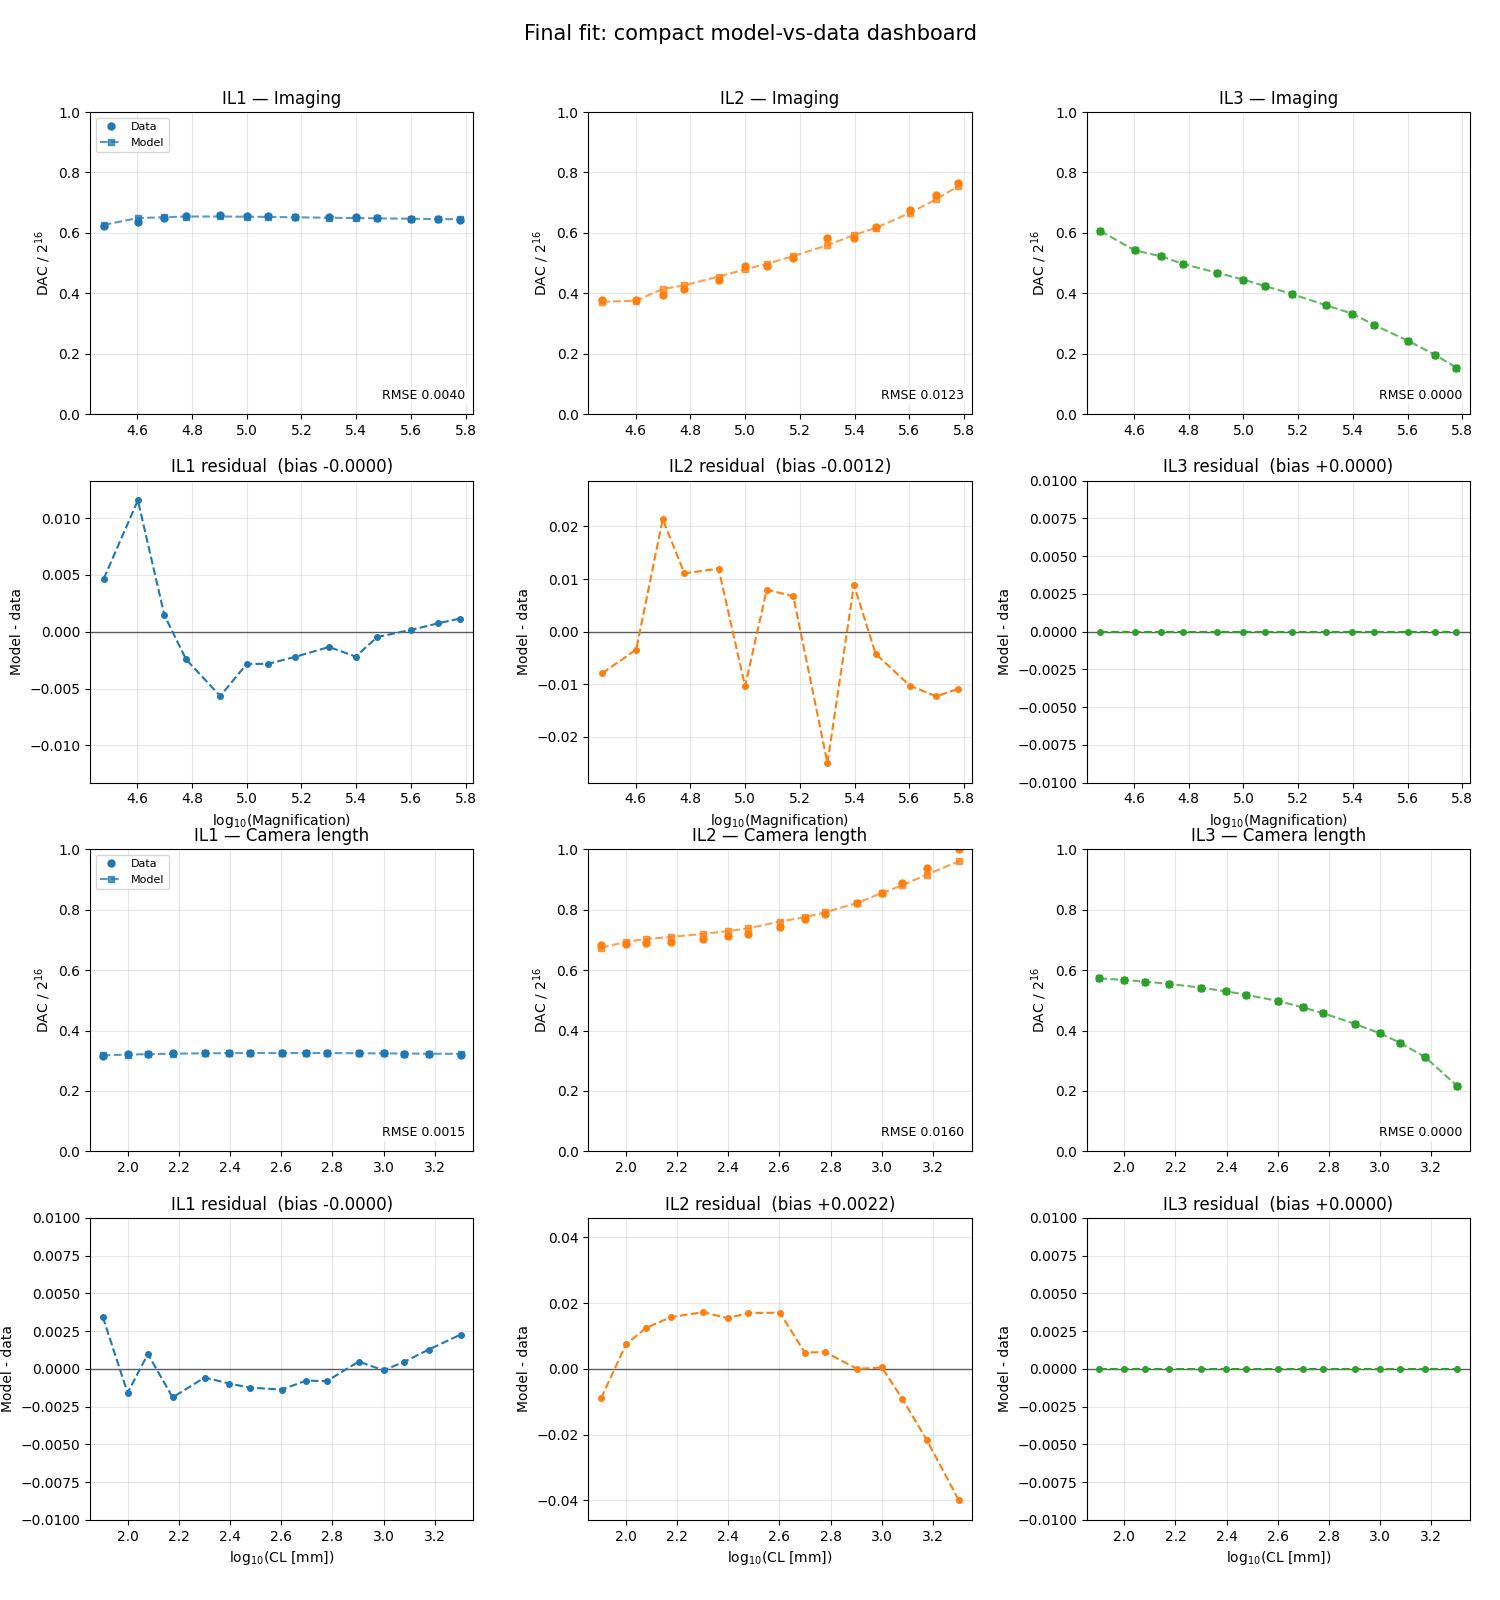

In [6]:
# ── Plot: compact model-vs-data dashboard (no zoom insets) ────────────

lens_names = ['IL1', 'IL2', 'IL3']
lens_colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

log_mags = np.log10(mags_ref)
log_cl = np.log10(cl_ref)
img_xlim = (log_mags.min() - 0.05, log_mags.max() + 0.05)
cam_xlim = (log_cl.min() - 0.05, log_cl.max() + 0.05)


def residual_limits(residual, pad=0.15):
    values = residual[np.isfinite(residual)]
    if values.size == 0:
        return -0.05, 0.05
    bound = np.max(np.abs(values))
    bound = max(bound * (1 + pad), 0.01)
    return -bound, bound


def residual_stats(pred, data):
    ok = np.isfinite(pred)
    residual = np.full_like(pred, np.nan)
    residual[ok] = pred[ok] - data[ok]
    rmse = np.sqrt(np.mean(residual[ok]**2)) if np.any(ok) else np.nan
    bias = np.mean(residual[ok]) if np.any(ok) else np.nan
    return residual, rmse, bias


for k, (name, color) in enumerate(zip(lens_names, lens_colors)):
    residual_img, rmse_img, bias_img = residual_stats(pi_f[k], x_img[k])
    residual_cam, rmse_cam, bias_cam = residual_stats(pc_f[k], x_cam[k])

    ax = axes[0, k]
    ok = np.isfinite(pi_f[k])
    ax.plot(log_mags, x_img[k], 'o', color=color, ms=5, label='Data')
    ax.plot(log_mags[ok], pi_f[k, ok], 's--', color=color, ms=4, alpha=0.75, label='Model')
    ax.set_xlim(*img_xlim)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('DAC / $2^{16}$')
    ax.set_title(f'{name} — Imaging')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.04, f'RMSE {rmse_img:.4f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))
    if k == 0:
        ax.legend(fontsize=8, loc='upper left')

    ax = axes[1, k]
    ok = np.isfinite(pi_f[k])
    ax.axhline(0.0, color='k', lw=1.0, alpha=0.6)
    ax.plot(log_mags[ok], residual_img[ok], 'o--', color=color, ms=4)
    ylo, yhi = residual_limits(residual_img)
    ax.set_xlim(*img_xlim)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Model - data')
    ax.set_xlabel('log$_{10}$(Magnification)')
    ax.set_title(f'{name} residual  (bias {bias_img:+.4f})')
    ax.grid(True, alpha=0.3)

    ax = axes[2, k]
    ok = np.isfinite(pc_f[k])
    ax.plot(log_cl, x_cam[k], 'o', color=color, ms=5, label='Data')
    ax.plot(log_cl[ok], pc_f[k, ok], 's--', color=color, ms=4, alpha=0.75, label='Model')
    ax.set_xlim(*cam_xlim)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('DAC / $2^{16}$')
    ax.set_title(f'{name} — Camera length')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.04, f'RMSE {rmse_cam:.4f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))
    if k == 0:
        ax.legend(fontsize=8, loc='upper left')

    ax = axes[3, k]
    ok = np.isfinite(pc_f[k])
    ax.axhline(0.0, color='k', lw=1.0, alpha=0.6)
    ax.plot(log_cl[ok], residual_cam[ok], 'o--', color=color, ms=4)
    ylo, yhi = residual_limits(residual_cam)
    ax.set_xlim(*cam_xlim)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Model - data')
    ax.set_xlabel('log$_{10}$(CL [mm])')
    ax.set_title(f'{name} residual  (bias {bias_cam:+.4f})')
    ax.grid(True, alpha=0.3)

fig.suptitle('Final fit: compact model-vs-data dashboard', fontsize=15, y=0.985)
fig.subplots_adjust(top=0.93, bottom=0.05, left=0.06, right=0.98, hspace=0.22, wspace=0.30)
plt.show()


## Export fitted geometry for microscope.toml

Convert the fitted normalised distances to absolute z-positions (metres) consistent
with the column geometry used in `microscope_design_curves.ipynb` and
`microscope.toml`.

The constraint study fits distances normalised to $d_3 = 1$ (the IL2→IL3 gap).
To recover physical distances we multiply by `D3_MM` (mm) then convert to metres.

Critical convention:
- $d_1^{img}$ is measured from the **objective image plane** to IL1, not from Obj_post.
- The objective image plane is computed from a chosen objective magnification
  ($M_{obj}$) and the sample-to-objective distance.

With objective lens at $z_{obj}$, sample at $z_s$, and $u = z_{obj} - z_s$:

$$v = |M_{obj}|\,u, \qquad z_{obj\_image} = z_{obj} + v$$

Then the fitted IL coordinates are

$$z_{IL1} = z_{obj\_image} + d_1^{img}, \quad
z_{IL2} = z_{IL1} + d_2, \quad
z_{IL3} = z_{IL2} + d_3, \quad
z_{PL1} = z_{IL3} + d_4.$$

For diffraction mode, $d_1^{cam}$ is interpreted as BFP-to-IL1 and is printed
alongside the value implied by the chosen objective geometry for consistency checks.

In [14]:
# -- Export: convert fitted distances to toml z-positions -----------------------
#
## Upstream geometry (source -> Obj_post) is fixed and taken from the
## existing microscope.toml / design_curves notebook.

# Upstream z-positions (metres) -- these are not fitted, just context.
Z_SOURCE       = 0.0
Z_CL1          = 0.2000
Z_CL3          = 0.2400
Z_APERTURE     = 0.2500
Z_CMINI        = 0.3000
Z_OBJ_PREFIELD = 0.3200
Z_SAMPLE       = 0.3250   # Obj_prefield + 5 mm
Z_OBJ_POST     = 0.3273   # Sample + 2.3 mm

# Fitted physical distances (metres).
d1_img_m = d1i_f * D3_MM * 1e-3   # objective_image_plane -> IL1 (imaging mode)
d1_cam_m = d1c_f * D3_MM * 1e-3   # BFP -> IL1 (camera-length mode)
d2_m = d2_f * D3_MM * 1e-3        # IL1 -> IL2
d3_m = D3_MM * 1e-3               # IL2 -> IL3 (reference gap)
d4_m = d4_f * D3_MM * 1e-3        # IL3 -> IL image plane (NOT PL1!)

# Objective geometry convention:
# d1_cam - d1_img = z_obj_image - z_BFP = v_obj - f_obj.
# Solve for |M_obj| from this fitted difference when possible.
u_obj_m = Z_OBJ_POST - Z_SAMPLE
delta_img_to_bfp_m = d1_cam_m - d1_img_m

M_OBJ_FOR_GEOMETRY = None  # Set a value like -30.0 to force it; None = infer from fitted distances.

if M_OBJ_FOR_GEOMETRY is None:
    m_obj_abs = _solve_m_obj_from_delta(delta_img_to_bfp_m, u_obj_m)
    if m_obj_abs is None:
        raise ValueError(
            "Cannot infer objective magnification from fitted d1 values: "
            f"d1_cam - d1_img = {delta_img_to_bfp_m*1e3:.3f} mm is not positive."
        )
    m_obj_signed = -float(m_obj_abs)
    objective_mode = "auto_from_fitted_d1"
else:
    m_obj_signed = float(M_OBJ_FOR_GEOMETRY)
    m_obj_abs = abs(m_obj_signed)
    objective_mode = "forced"

v_obj_m = m_obj_abs * u_obj_m
f_obj_m = (u_obj_m * v_obj_m) / (u_obj_m + v_obj_m)
z_bfp = Z_OBJ_POST + f_obj_m
z_obj_image = Z_OBJ_POST + v_obj_m

# Derive z-positions from objective-image convention.
z_il1 = z_obj_image + d1_img_m
z_il2 = z_il1 + d2_m
z_il3 = z_il2 + d3_m
z_il_image = z_il3 + d4_m          # where B=0 for the 3-lens IL block

# Detector z-position from shared CAD geometry constants.
z_detector = Z_SAMPLE + CAD_SAMPLE_TO_DET_MM * 1e-3

# ── PL1: calibrate Gc from the fit's scale factor ────────────────────
# The fit determined s_img such that m_IL = si * s_img * mag_ref.
# The total magnification factors as M_total = M_obj * m_IL * M_PL1,
# so |M_PL1| = 1 / (|M_obj| * s_img).
_PL1_I     = -3.116334138300715    # coil current [A] (constant across modes)
_PL1_TURNS = 2000
_NI_PL1    = _PL1_TURNS * abs(_PL1_I)

M_PL1_required = 1.0 / (m_obj_abs * s_img_f)

# Self-consistent PL1 position from required magnification:
# D = z_det - z_il_image (total IL_image -> Detector)
# u = D / (1 + |M_PL1|),  v = D - u,  f = u*v/D
D_img_to_det = z_detector - z_il_image
u_pl1_m = D_img_to_det / (1.0 + M_PL1_required)
v_pl1_m = D_img_to_det - u_pl1_m
f_pl1_m = u_pl1_m * v_pl1_m / D_img_to_det

# Derive PL1 Gc from the required focal length: 1/f = Gc * NI^2
Gc_PL1_calibrated = 1.0 / (f_pl1_m * _NI_PL1**2)

z_pl1 = z_il_image + u_pl1_m

# Consistency check against camera-mode convention (BFP -> IL1).
d1_cam_from_geom_m = z_il1 - z_bfp
d1_cam_delta_m = d1_cam_from_geom_m - d1_cam_m

print(f"Objective geometry ({objective_mode}): M_obj = {m_obj_signed:+.6f}")
print(f"  u = {u_obj_m*1e3:.3f} mm,  v = {v_obj_m*1e3:.3f} mm,  f = {f_obj_m*1e3:.3f} mm")
print(f"\nPL1 calibration from fit scale factor:")
print(f"  s_img = {s_img_f:.6e}  =>  |M_obj * M_PL1| = {1/s_img_f:.2f}")
print(f"  Required |M_PL1| = {M_PL1_required:.4f}")
print(f"  IL_image->Det D = {D_img_to_det*1e3:.3f} mm")
print(f"  u_PL1 = {u_pl1_m*1e3:.4f} mm,  v_PL1 = {v_pl1_m*1e3:.3f} mm")
print(f"  f_PL1 = {f_pl1_m*1e3:.4f} mm")
print(f"  Gc_PL1 = {Gc_PL1_calibrated:.6e}  (was 8.0e-6)")
print(f"  M_PL1 = {-v_pl1_m/u_pl1_m:.2f}")
print(f"\nFitted IL z-positions:")
print(f"  z_IL1 = {z_il1:.9f} m")
print(f"  z_IL2 = {z_il2:.9f} m")
print(f"  z_IL3 = {z_il3:.9f} m")
print(f"  z_IL_img = {z_il_image:.9f} m  (IL image plane)")
print(f"  z_PL1 = {z_pl1:.9f} m  (= z_IL_img + u_PL1)")
print(f"  z_Det = {z_detector:.9f} m")
print(f"  PL1->Det = {v_pl1_m*1e3:.1f} mm")
print(f"\nBFP-to-IL1 consistency: fitted = {d1_cam_m*1e3:.3f} mm, "
      f"geometry = {d1_cam_from_geom_m*1e3:.3f} mm, delta = {d1_cam_delta_m*1e3:+.3f} mm")

Objective geometry (auto_from_fitted_d1): M_obj = -80.823334
  u = 2.300 mm,  v = 185.894 mm,  f = 2.272 mm

PL1 calibration from fit scale factor:
  s_img = 1.115337e-04  =>  |M_obj * M_PL1| = 8965.90
  Required |M_PL1| = 110.9321
  IL_image->Det D = 322.320 mm
  u_PL1 = 2.8796 mm,  v_PL1 = 319.440 mm
  f_PL1 = 2.8539 mm
  Gc_PL1 = 9.020208e-06  (was 8.0e-6)
  M_PL1 = -110.93

Fitted IL z-positions:
  z_IL1 = 0.529741714 m
  z_IL2 = 0.606847185 m
  z_IL3 = 0.669347185 m
  z_IL_img = 0.721429942 m  (IL image plane)
  z_PL1 = 0.724309547 m  (= z_IL_img + u_PL1)
  z_Det = 1.043750000 m
  PL1->Det = 319.4 mm

BFP-to-IL1 consistency: fitted = 200.170 mm, geometry = 200.170 mm, delta = +0.000 mm


## Export IL tables for microscope_design_curves

Save the calibrated DAC tables and lens constants to an NPZ file so that
`microscope_design_curves.ipynb` can load them directly instead of
independently re-solving the IL operating points.

In [8]:
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
il_export_path = _repo / 'examples/microscope_models/data/il_constraint_study.npz'
il_export_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    il_export_path,
    # Calibration parameters
    D3_MM   = D3_MM,
    alpha_f = alpha_f,
    d1i_f   = d1i_f,
    d1c_f   = d1c_f,
    d2_f    = d2_f,
    d4_f    = d4_f,
    si_best = si_best,
    sc_best = sc_best,
    s_img_f = s_img_f,
    s_cam_f = s_cam_f,
    # Imaging mode: 3 lenses × n_img operating points
    x_img    = x_img,
    mags_ref = mags_ref,
    # Diffraction mode: 3 lenses × n_diff operating points
    # cl_ref_m stores camera lengths in metres (cl_ref in notebook is mm)
    x_cam    = x_cam,
    cl_ref_m = cl_ref * 1e-3,
)

print(f'Saved IL constraint study export to: {il_export_path}')
print(f'  Imaging:     {x_img.shape[1]} points,  mags {mags_ref.min():.0f} .. {mags_ref.max():.0f}')
print(f'  Diffraction: {x_cam.shape[1]} points,  CL {cl_ref.min():.0f} .. {cl_ref.max():.0f} mm')
print(f'  alpha_f = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]')
print(f'  D3_MM = {D3_MM:.2f} mm')

Saved IL constraint study export to: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/data/il_constraint_study.npz
  Imaging:     14 points,  mags 30000 .. 600000
  Diffraction: 15 points,  CL 80 .. 2000 mm
  alpha_f = [11.2158, 17.1740, 6.6581]
  D3_MM = 62.50 mm


PL1 optical power: phi = 310.77 m^-1  (f = 3.218 mm)
PL1 object distance: u = 3.250 mm  (0.0520 d3)
PL1 image distance:  v = 325.0 mm  (5.200 d3)
PL1 magnification:  M_PL1 = -100.0
Sample->Detector (CAD): 718.8 mm


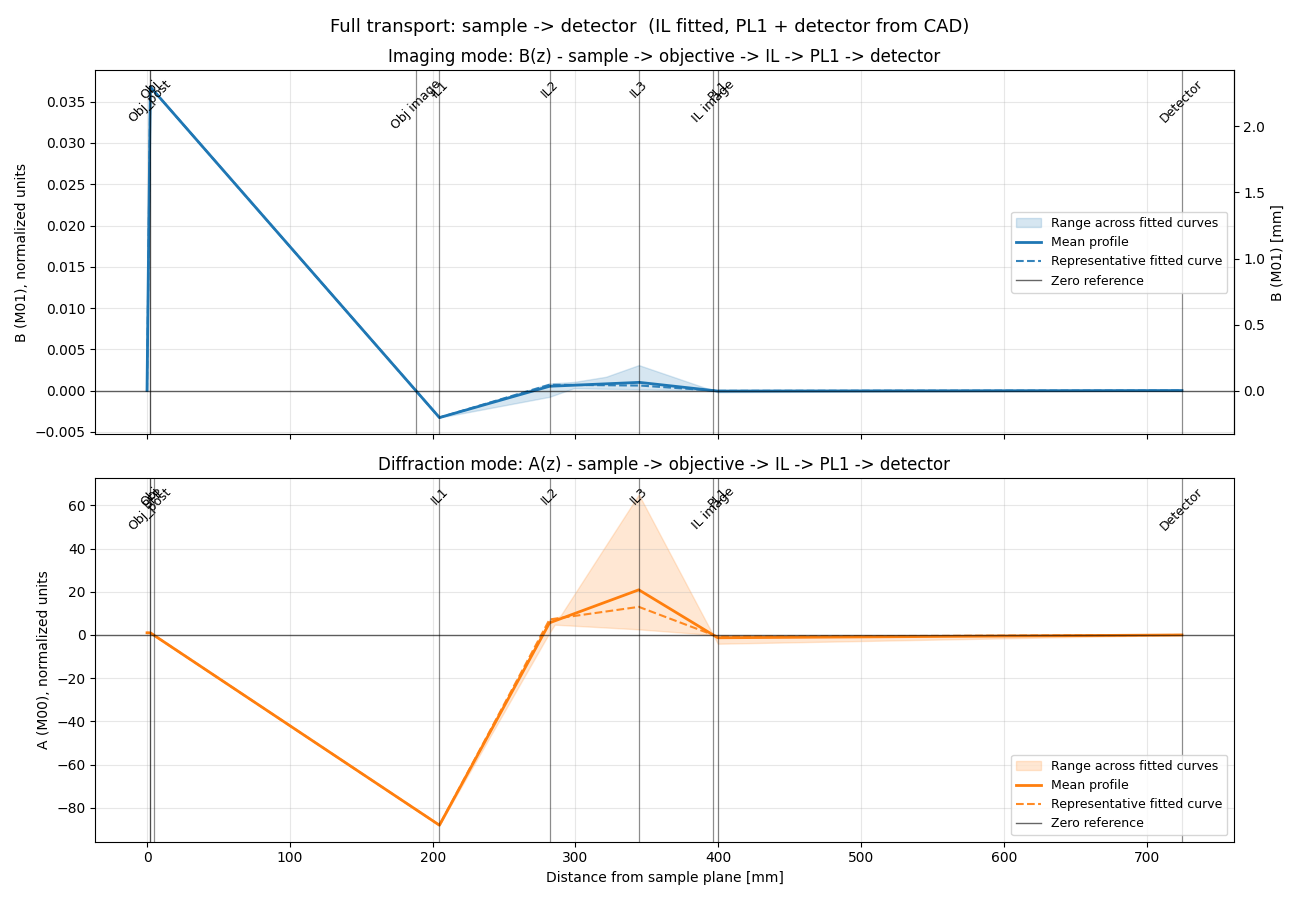


Sample->Detector distance in model: 724.7 mm  (CAD: 718.8 mm)
Imaging endpoint B at detector: -8.112e-13 .. -4.213e-14 (normalized)
                                  -5.070e-11 .. -2.633e-12 mm
Diffraction endpoint A at detector: -6.073e-11 .. +1.773e-10

Objective for profile: |M_obj| = 80.823334, f_obj = 2.272 mm
PL1 object distance: u = 3.250 mm,  image distance: v = 325.0 mm


In [9]:
# Plot transport evolution: sample -> objective -> IL -> PL1 -> detector.
from temgym_core.transfer_matrices import propagation_matrix, lens_matrix  # needed for profile sampling


def build_profile_from_elements(elements, component='B', samples_per_drift=140):
    """Return z-grid and selected transfer component in normalized units.

    elements: list of tuples (kind, value, marker_label_or_None)
      kind='P' for drift, 'L' for lens (value = lens power phi).
    component: 'A' or 'B' for M00 / M01 profile.
    """
    comp_idx = {'A': (0, 0), 'B': (0, 1)}
    if component not in comp_idx:
        raise ValueError("component must be 'A' or 'B'")
    irow, icol = comp_idx[component]

    M = np.eye(3)
    z_now = 0.0
    z_all = [0.0]
    val_all = [M[irow, icol]]
    markers = []

    for kind, value, marker in elements:
        if kind == 'P':
            L = float(value)
            local = np.linspace(0.0, L, samples_per_drift, endpoint=False)[1:]
            for t in local:
                Mt = propagation_matrix(t, xp=np) @ M
                z_all.append(z_now + t)
                val_all.append(Mt[irow, icol])

            M = propagation_matrix(L, xp=np) @ M
            z_now += L
            z_all.append(z_now)
            val_all.append(M[irow, icol])
            if marker is not None:
                markers.append((z_now, str(marker)))

        elif kind == 'L':
            phi = float(value)
            M = lens_matrix(1.0 / phi, xp=np) @ M
            z_all.append(z_now)
            val_all.append(M[irow, icol])
            if marker is not None:
                markers.append((z_now, str(marker)))

        else:
            raise ValueError(f"Unknown element kind: {kind}")

    return np.asarray(z_all), np.asarray(val_all), markers


def mode_profile_stack(elements_builder, alpha, x_mode, d3_mm, component='B'):
    phi_all = alpha[:, None] * (x_mode**2)

    elems0 = elements_builder(phi_all[:, 0])
    z_ref, v_ref, markers = build_profile_from_elements(elems0, component=component)
    V_stack = np.empty((phi_all.shape[1], v_ref.size), dtype=float)
    V_stack[0] = v_ref

    for j in range(1, phi_all.shape[1]):
        elems_j = elements_builder(phi_all[:, j])
        z_j, v_j, _ = build_profile_from_elements(elems_j, component=component)
        if z_j.size != z_ref.size or np.max(np.abs(z_j - z_ref)) > 1e-12:
            v_j = np.interp(z_ref, z_j, v_j)
        V_stack[j] = v_j

    z_ref_mm = z_ref * float(d3_mm)
    markers_mm = [(z * float(d3_mm), label) for z, label in markers]

    return z_ref_mm, V_stack, markers_mm


# Objective block: reuse m_obj_abs from export cell, derive normalised values.
u_obj_norm = u_obj_m / (D3_MM * 1e-3)
v_obj_norm = m_obj_abs * u_obj_norm
f_obj_norm = (u_obj_norm * v_obj_norm) / (u_obj_norm + v_obj_norm)
phi_obj_norm = 1.0 / f_obj_norm

# ── PL1 + detector from shared CAD geometry ──────────────────────────
# PL1 optical power from the constant excitation in the mode tables.
_PL1_I      = -3.116334138300715   # coil current [A] (constant across modes)
_PL1_TURNS  = 2000
_PL1_GC     = 8.0e-6              # Gc from microscope.toml
_NI_PL1     = _PL1_TURNS * abs(_PL1_I)
phi_pl1_m   = _PL1_GC * _NI_PL1**2            # 1/f in m^{-1}
phi_pl1_norm = phi_pl1_m * (D3_MM * 1e-3)     # normalised to d3 units
f_pl1_mm    = 1.0 / phi_pl1_m * 1e3           # focal length in mm

d_pl1_det_mm = CAD_PL1_TO_DET_MM
d_pl1_det_norm = d_pl1_det_mm / D3_MM
d_sample_det_mm = CAD_SAMPLE_TO_DET_MM

# PL1 object distance from thin-lens equation: 1/u = 1/f - 1/v
# The IL image must land at u_pl1 before PL1 (the object plane), not at PL1 itself.
u_pl1_mm   = f_pl1_mm * d_pl1_det_mm / (d_pl1_det_mm - f_pl1_mm)
u_pl1_norm = u_pl1_mm / D3_MM

print(f"PL1 optical power: phi = {phi_pl1_m:.2f} m^-1  (f = {f_pl1_mm:.3f} mm)")
print(f"PL1 object distance: u = {u_pl1_mm:.3f} mm  ({u_pl1_norm:.4f} d3)")
print(f"PL1 image distance:  v = {d_pl1_det_mm:.1f} mm  ({d_pl1_det_norm:.3f} d3)")
print(f"PL1 magnification:  M_PL1 = {-d_pl1_det_mm/u_pl1_mm:.1f}")
print(f"Sample->Detector (CAD): {d_sample_det_mm:.1f} mm")


def _elements_imaging(phi_il):
    return [
        ('P', u_obj_norm, 'Obj_post'),
        ('L', phi_obj_norm, 'Obj'),
        ('P', v_obj_norm, 'Obj image'),
        ('P', float(d1i_f), 'IL1'),
        ('L', float(phi_il[0]), None),
        ('P', float(d2_f), 'IL2'),
        ('L', float(phi_il[1]), None),
        ('P', 1.0, 'IL3'),
        ('L', float(phi_il[2]), None),
        ('P', float(d4_f), 'IL image'),       # IL3 -> IL image (= PL1 object plane)
        ('P', u_pl1_norm, 'PL1'),              # PL1 object plane -> PL1 lens
        ('L', phi_pl1_norm, None),             # PL1 thin lens
        ('P', d_pl1_det_norm, 'Detector'),     # PL1 -> Detector
    ]


def _elements_diffraction(phi_il):
    return [
        ('P', u_obj_norm, 'Obj_post'),
        ('L', phi_obj_norm, 'Obj'),
        ('P', f_obj_norm, 'BFP'),
        ('P', float(d1c_f), 'IL1'),
        ('L', float(phi_il[0]), None),
        ('P', float(d2_f), 'IL2'),
        ('L', float(phi_il[1]), None),
        ('P', 1.0, 'IL3'),
        ('L', float(phi_il[2]), None),
        ('P', float(d4_f), 'IL image'),       # IL3 -> IL image (= PL1 object plane)
        ('P', u_pl1_norm, 'PL1'),              # PL1 object plane -> PL1 lens
        ('L', phi_pl1_norm, None),             # PL1 thin lens
        ('P', d_pl1_det_norm, 'Detector'),     # PL1 -> Detector
    ]


z_img_mm, B_img, markers_img = mode_profile_stack(
    _elements_imaging, alpha_f, pi_f, D3_MM, component='B'
)
z_cam_mm, A_cam, markers_cam = mode_profile_stack(
    _elements_diffraction, alpha_f, pc_f, D3_MM, component='A'
)

idx_img_mid = B_img.shape[0] // 2
idx_cam_mid = A_cam.shape[0] // 2

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for ax, z_mm, V_mode, markers, title, color, idx_mid, y_label in [
    (axes[0], z_img_mm, B_img, markers_img,
     'Imaging mode: B(z) - sample -> objective -> IL -> PL1 -> detector', 'C0', idx_img_mid, 'B (M01), normalized units'),
    (axes[1], z_cam_mm, A_cam, markers_cam,
     'Diffraction mode: A(z) - sample -> objective -> IL -> PL1 -> detector', 'C1', idx_cam_mid, 'A (M00), normalized units'),
]:
    v_min = np.nanmin(V_mode, axis=0)
    v_max = np.nanmax(V_mode, axis=0)
    v_mean = np.nanmean(V_mode, axis=0)

    ax.fill_between(z_mm, v_min, v_max, color=color, alpha=0.18, label='Range across fitted curves')
    ax.plot(z_mm, v_mean, color=color, lw=2.0, label='Mean profile')
    ax.plot(z_mm, V_mode[idx_mid], color=color, ls='--', lw=1.5, alpha=0.9, label='Representative fitted curve')

    for z_mark, label in markers:
        ax.axvline(z_mark, color='k', lw=0.9, alpha=0.45)
        ax.text(z_mark, 0.98, label, transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=9, rotation=45)

    ax.axhline(0.0, color='k', lw=1.0, alpha=0.6, label='Zero reference')
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

# Also expose B in physical units on a secondary y-axis.
b_to_mm = lambda y: y * D3_MM
mm_to_b = lambda y: y / D3_MM
secax_b = axes[0].secondary_yaxis('right', functions=(b_to_mm, mm_to_b))
secax_b.set_ylabel('B (M01) [mm]')

axes[-1].set_xlabel('Distance from sample plane [mm]')
fig.suptitle('Full transport: sample -> detector  (IL fitted, PL1 + detector from CAD)', fontsize=13, y=0.98)
fig.tight_layout()
plt.show()

# Report sample->detector distance and endpoint values.
z_det_from_sample_mm = z_mm[-1]  # last point is detector
b_det_min = np.nanmin(B_img[:, -1])
b_det_max = np.nanmax(B_img[:, -1])
print(f'\nSample->Detector distance in model: {z_det_from_sample_mm:.1f} mm  (CAD: {d_sample_det_mm:.1f} mm)')
print(f'Imaging endpoint B at detector: {b_det_min:+.3e} .. {b_det_max:+.3e} (normalized)')
print(f'                                  {b_to_mm(b_det_min):+.3e} .. {b_to_mm(b_det_max):+.3e} mm')
print(f'Diffraction endpoint A at detector: {np.nanmin(A_cam[:, -1]):+.3e} .. {np.nanmax(A_cam[:, -1]):+.3e}')
print(f'\nObjective for profile: |M_obj| = {m_obj_abs:.6f}, f_obj = {f_obj_norm*D3_MM:.3f} mm')
print(f'PL1 object distance: u = {u_pl1_mm:.3f} mm,  image distance: v = {d_pl1_det_mm:.1f} mm')


## Validation: autodiff ABCD vs manual profile

Compare the manual `build_profile_from_elements` B(z) profile against
`solve_model_with_z` which uses `jax.jacobian` on actual `Lens` components.
The two approaches should agree to numerical precision at every component
boundary.

Max |B_manual - B_auto| at component boundaries: 3.36e-04
Autodiff B at detector: 3.357598e-04
Manual  B at detector:  -2.058499e-13


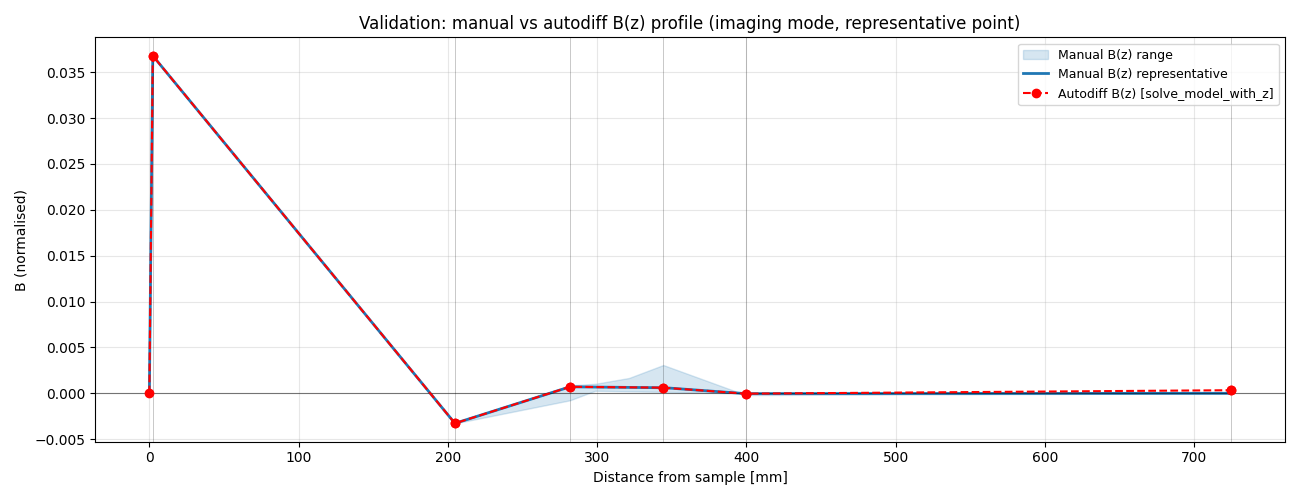

In [10]:
from temgym_core.ray import Ray
from temgym_core.components import Lens, Plane
from temgym_core.run import solve_model_with_z
from temgym_core.plotting import plot_abcd_profile

# Build Component-based IL system at the same normalised z-positions
# as the manual transport profile above.
#
# The manual system is:
#   sample(z=0) -> P(u_obj) -> Obj -> P(v_obj) -> P(d1) -> IL1 -> P(d2) -> IL2
#   -> P(d3) -> IL3 -> P(d4) -> P(u_pl1) -> PL1 -> P(d_pl1_det) -> Detector
#
# For solve_model_with_z, each component sits at an absolute z coordinate.

z_obj_comp = u_obj_norm  # objective lens z
z_il1_comp = z_obj_comp + v_obj_norm + d1i_f
z_il2_comp = z_il1_comp + d2_f
z_il3_comp = z_il2_comp + 1.0  # d3 = 1.0 normalised
z_pl1_comp = z_il3_comp + d4_f + u_pl1_norm
z_det_comp = z_pl1_comp + d_pl1_det_norm

column_norm = [
    Lens(z=z_obj_comp, focal_length=1.0 / phi_obj_norm),
    Lens(z=z_il1_comp, focal_length=1.0 / (alpha_f[0] * pi_f[0, idx_img_mid]**2)),
    Lens(z=z_il2_comp, focal_length=1.0 / (alpha_f[1] * pi_f[1, idx_img_mid]**2)),
    Lens(z=z_il3_comp, focal_length=1.0 / (alpha_f[2] * pi_f[2, idx_img_mid]**2)),
    Lens(z=z_pl1_comp, focal_length=1.0 / phi_pl1_norm),
    Plane(z=z_det_comp),
]
col_names = ['Obj', 'IL1', 'IL2', 'IL3', 'PL1', 'Detector']

ray0 = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=0.0, pathlength=0.0, voltage=200e3)
z_auto, cum_auto, labels_auto, _rot = solve_model_with_z(ray0, column_norm, names=col_names)

# Convert to mm for overlay on the manual profile
z_auto_mm = np.array(z_auto) * D3_MM

# Extract auto B (M[0,2] in 5×5 = M[0,1] in 3×3)
auto_B = np.array(cum_auto[:, 0, 2])

# ── Overlay on the manual B(z) profile ──
fig, ax = plt.subplots(figsize=(13, 5))

# Manual envelope (from transport cell)
v_min = np.nanmin(B_img, axis=0)
v_max = np.nanmax(B_img, axis=0)
ax.fill_between(z_img_mm, v_min, v_max, color='C0', alpha=0.18, label='Manual B(z) range')
ax.plot(z_img_mm, B_img[idx_img_mid], color='C0', lw=2, label='Manual B(z) representative')

# Autodiff overlay
ax.plot(z_auto_mm, auto_B, 'ro--', ms=6, lw=1.5, zorder=10,
        label='Autodiff B(z) [solve_model_with_z]')

# Component markers
for zm, lbl in zip(z_auto_mm, labels_auto):
    if lbl not in ('source', 'drift'):
        ax.axvline(zm, color='k', lw=0.5, alpha=0.3)

ax.axhline(0, color='k', lw=0.8, alpha=0.5)
ax.set_xlabel('Distance from sample [mm]')
ax.set_ylabel('B (normalised)')
ax.set_title('Validation: manual vs autodiff B(z) profile (imaging mode, representative point)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()

# Numerical comparison at matching boundaries
max_diff = np.max(np.abs(auto_B[auto_B != 0] - np.interp(
    z_auto_mm[auto_B != 0], z_img_mm, B_img[idx_img_mid])))
print(f"Max |B_manual - B_auto| at component boundaries: {max_diff:.2e}")
print(f"Autodiff B at detector: {auto_B[-1]:.6e}")
print(f"Manual  B at detector:  {B_img[idx_img_mid, -1]:.6e}")

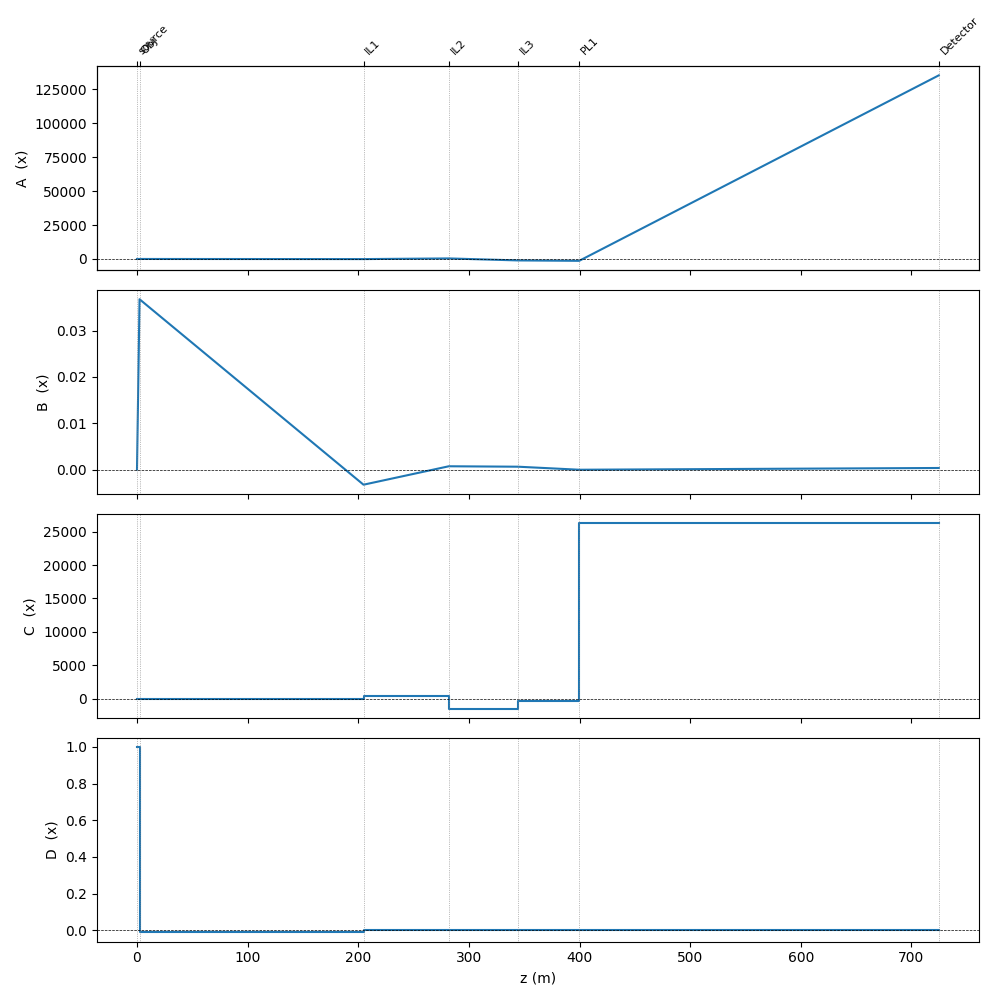

In [11]:
# Full ABCD profile — all four matrix elements
fig, axes = plot_abcd_profile(z_auto_mm, cum_auto, labels=labels_auto)
fig.suptitle('ABCD profile (imaging mode, representative point, normalised units)', y=1.02);

In [ ]:
# Write fitted IL operating tables and fitted lens positions back to microscope.toml.
import tomlkit
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
toml_path = _repo / 'examples/microscope_models/microscope.toml'

doc = tomlkit.parse(toml_path.read_text(encoding='utf-8'))

# Update lens z-positions (computed in the export cell above).
doc['lenses']['IL1']['z_m'] = z_il1
doc['lenses']['IL2']['z_m'] = z_il2
doc['lenses']['IL3']['z_m'] = z_il3
doc['lenses']['PL1']['z_m'] = z_pl1

# Update PL1 Gc from the calibrated value (derived from fit scale factor).
doc['lenses']['PL1']['Gc'] = float(Gc_PL1_calibrated)

# Update detector z-position from CAD pixel measurement.
doc['detector']['z_m'] = z_detector

# ── Convert DAC fractions (x) to physical coil currents (Amps) ──────
# The fit uses normalised optical power:  phi_norm = alpha_k * x_k^2
# Physical optical power:                 phi_phys = phi_norm / d3_m
# TOML convention at reference voltage:   phi_phys = Gc_toml * (N * I)^2
# Therefore:  I_k = x_k * sqrt(alpha_k / (d3_m * Gc_toml * N^2))
d3_m_val = D3_MM * 1e-3  # d3 in metres

il_lens_names = ['IL1', 'IL2', 'IL3']
il_turns = np.array([float(doc['lenses'][n]['turns']) for n in il_lens_names])
il_gc    = np.array([float(doc['lenses'][n]['Gc'])    for n in il_lens_names])

# I_max_k converts x_k (DAC fraction) to I_k (Amps):  I_k = x_k * I_max_k
I_max = np.sqrt(alpha_f / (d3_m_val * il_gc * il_turns**2))

print("DAC → current conversion factors (I_max per lens):")
for k, name in enumerate(il_lens_names):
    print(f"  {name}: I_max = {I_max[k]:.6f} A  (N={il_turns[k]:.0f}, Gc={il_gc[k]:.2e})")

# Convert model-predicted DAC arrays to physical currents
pi_f_amps = pi_f * I_max[:, None]   # imaging mode
pc_f_amps = pc_f * I_max[:, None]   # diffraction mode

# Update magnification table with physical IL currents.
mag_tbl = doc['modes']['imaging']['magnification']
mag_idx = {k: i for i, k in enumerate(mag_tbl['headers'])}
new_mag_rows = []
for j in range(len(mags_ref)):
    row = list(mag_tbl['values'][j]) if j < len(mag_tbl['values']) else [0.0] * len(mag_tbl['headers'])
    row[mag_idx['mag']] = float(mags_ref[j])
    row[mag_idx['IL1']] = float(pi_f_amps[0, j])
    row[mag_idx['IL2']] = float(pi_f_amps[1, j])
    row[mag_idx['IL3']] = float(pi_f_amps[2, j])
    new_mag_rows.append(row)
mag_tbl['values'] = new_mag_rows

# Update diffraction table with physical IL currents.
diff_tbl = doc['modes']['imaging']['diffraction']
diff_idx = {k: i for i, k in enumerate(diff_tbl['headers'])}
existing_cam = [float(r[diff_idx['camera_length']]) for r in diff_tbl['values']] if diff_tbl['values'] else [1.0]
use_mm = max(existing_cam) > 5.0
cam_control = cl_ref if use_mm else cl_ref * 1e-3

new_diff_rows = []
for j in range(len(cam_control)):
    row = list(diff_tbl['values'][j]) if j < len(diff_tbl['values']) else [0.0] * len(diff_tbl['headers'])
    row[diff_idx['camera_length']] = float(cam_control[j])
    row[diff_idx['IL1']] = float(pc_f_amps[0, j])
    row[diff_idx['IL2']] = float(pc_f_amps[1, j])
    row[diff_idx['IL3']] = float(pc_f_amps[2, j])
    new_diff_rows.append(row)
diff_tbl['values'] = new_diff_rows

toml_path.write_text(tomlkit.dumps(doc), encoding='utf-8')

# Verify the written file parses correctly.
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
with open(toml_path, 'rb') as f:
    _ = tomllib.load(f)

print(f"\nUpdated microscope config: {toml_path}")
print(f"  magnification rows: {len(new_mag_rows)}")
print(f"  diffraction rows:   {len(new_diff_rows)}  (camera_length unit: {'mm' if use_mm else 'm'})")
print(f"  lens z: IL1={z_il1:.9f}, IL2={z_il2:.9f}, IL3={z_il3:.9f}, PL1={z_pl1:.9f}")
print(f"  PL1 Gc: {Gc_PL1_calibrated:.6e}  (calibrated from fit)")
print(f"  detector z: {z_detector:.9f}  (PL1->Det = {v_pl1_m*1e3:.1f} mm)")
print(f"  M_obj = {m_obj_signed:+.6f} ({objective_mode})")
print(f"  |M_PL1| = {M_PL1_required:.2f}")
print(f"  BFP-to-IL1 consistency: delta = {d1_cam_delta_m*1e3:+.3f} mm")
print(f"\nSample IL1 current at mag=100k: DAC x={pi_f[0, 5]:.4f} -> I={pi_f_amps[0, 5]:.4f} A")

DAC → current conversion factors (I_max per lens):
  IL1: I_max = 3.999994 A  (N=3000, Gc=1.25e-06)
  IL2: I_max = 4.000003 A  (N=2000, Gc=4.29e-06)
  IL3: I_max = 4.000040 A  (N=2000, Gc=1.66e-06)

Updated microscope config: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/microscope.toml
  magnification rows: 14
  diffraction rows:   15  (camera_length unit: m)
  lens z: IL1=0.529741714, IL2=0.606847185, IL3=0.669347185, PL1=0.724309547
  PL1 Gc: 9.020208e-06  (calibrated from fit)
  detector z: 1.043750000  (PL1->Det = 319.4 mm)
  M_obj = -80.823334 (auto_from_fitted_d1)
  |M_PL1| = 110.93
  BFP-to-IL1 consistency: delta = +0.000 mm

Sample IL1 current at mag=100k: DAC x=0.6534 -> I=2.6137 A


: 